In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [23]:
df = pd.read_csv("CombinedData.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna().sort_values("Date").set_index("Date")

d = df.copy()
print(f"Original data shape: {d.shape}")
print(f"Date range: {d.index.min()} to {d.index.max()}")
print(f"Gold price range: ${d['gold_price'].min():.2f} - ${d['gold_price'].max():.2f}")

d['price_change'] = d['gold_price'].diff()
d['pct_change'] = d['gold_price'].pct_change()

# Analyze stagnant periods
stagnant_mask = (d['price_change'] == 0)
stagnant_count = stagnant_mask.sum()
stagnant_periods = stagnant_mask.astype(int).groupby((~stagnant_mask).cumsum()).sum()
max_stagnant_days = stagnant_periods.max()
print(f"Days with no price change: {stagnant_count} ({stagnant_count/len(d)*100:.2f}%)")
print(f"Longest stagnant period: {max_stagnant_days} days")

if max_stagnant_days > 1:
    print("\nWarning: Multiple consecutive days with no price change detected!")
    
d_filtered = d[~((d['price_change'] == 0) & (d['price_change'].shift(-1) == 0))].copy()
print(f"Original rows: {len(d)}")
print(f"Filtered rows: {len(d_filtered)}")
print(f"Rows removed: {len(d) - len(d_filtered)}")
print(f"Gold price range still: ${d_filtered['gold_price'].min():.2f} - ${d_filtered['gold_price'].max():.2f}")

# Drop the temporary columns
d_filtered = d_filtered.drop(['price_change', 'pct_change'], axis=1)

d = d_filtered.copy()
d.head()

Original data shape: (17170, 5)
Date range: 2003-01-02 00:00:00 to 2026-02-25 17:00:00
Gold price range: $2033.90 - $5591.00
Days with no price change: 5829 (33.95%)
Longest stagnant period: 5517 days

Original rows: 17170
Filtered rows: 11506
Rows removed: 5664
Gold price range still: $2033.90 - $5591.00


,gold_price,volatility,tips_yield,inflation,dollar_index
Date,,,,,
2003-01-02 00:00:00,2043.500000,14.19,2.43,1.98,101.4155
2024-02-25 23:00:00,2043.500000,14.19,1.96,2.26,121.0369
2024-02-26 00:00:00,2040.000000,14.19,1.97,2.26,121.0592
2024-02-26 01:00:00,2041.099976,14.19,1.97,2.26,121.0592
2024-02-26 02:00:00,2040.599976,14.19,1.97,2.26,121.0592


In [24]:
# Price-based features
d["gold_lag_1"] = d["gold_price"].shift(1)  # Previous day's price
d["gold_lag_2"] = d["gold_price"].shift(2)  # Price from 2 days ago
d["gold_lag_2"] = d["gold_price"].shift(3)  # Price from 3 days ago
d["gold_lag_5"] = d["gold_price"].shift(5)  # Price from 5 days ago
d["gold_lag_7"] = d["gold_price"].shift(7)  # Price from a week ago

d["gold_ret"] = d["gold_price"].pct_change()
d["gold_ret_lag_1"] = d["gold_ret"].shift(1)

# Derived features
d["real_yield"] = d["tips_yield"] - d["inflation"]
d["dxy_change"] = d["dollar_index"].pct_change()
d["vol_change"] = d["volatility"].pct_change()

# Base features for lag analysis 
base_features = ["gold_price", "volatility", "tips_yield", "inflation", "dollar_index", 
                 "real_yield", "dxy_change", "vol_change", "gold_ret"]

print("Base features created:")
for feat in base_features:
    print(f"  - {feat}")
    
d[base_features].head()

Base features created:
  - gold_price
  - volatility
  - tips_yield
  - inflation
  - dollar_index
  - real_yield
  - dxy_change
  - vol_change
  - gold_ret


,gold_price,volatility,tips_yield,inflation,dollar_index,real_yield,dxy_change,vol_change,gold_ret
Date,,,,,,,,,
2003-01-02 00:00:00,2043.500000,14.19,2.43,1.98,101.4155,0.45,NaN,NaN,NaN
2024-02-25 23:00:00,2043.500000,14.19,1.96,2.26,121.0369,-0.30,0.193475,0.0,0.000000
2024-02-26 00:00:00,2040.000000,14.19,1.97,2.26,121.0592,-0.29,0.000184,0.0,-0.001713
2024-02-26 01:00:00,2041.099976,14.19,1.97,2.26,121.0592,-0.29,0.000000,0.0,0.000539
2024-02-26 02:00:00,2040.599976,14.19,1.97,2.26,121.0592,-0.29,0.000000,0.0,-0.000245


In [25]:
d = d.dropna()
d[base_features].head()

,gold_price,volatility,tips_yield,inflation,dollar_index,real_yield,dxy_change,vol_change,gold_ret
Date,,,,,,,,,
2024-02-26 05:00:00,2042.500000,14.19,1.97,2.26,121.0592,-0.29,0.0,0.000000,0.000392
2024-02-26 06:00:00,2042.300049,14.19,1.97,2.26,121.0592,-0.29,0.0,0.000000,-0.000098
2024-02-26 07:00:00,2044.500000,14.19,1.97,2.26,121.0592,-0.29,0.0,0.000000,0.001077
2024-02-26 08:00:00,2043.599976,14.19,1.97,2.26,121.0592,-0.29,0.0,0.000000,-0.000440
2024-02-26 09:00:00,2042.400024,14.13,1.97,2.26,121.0592,-0.29,0.0,-0.004228,-0.000587


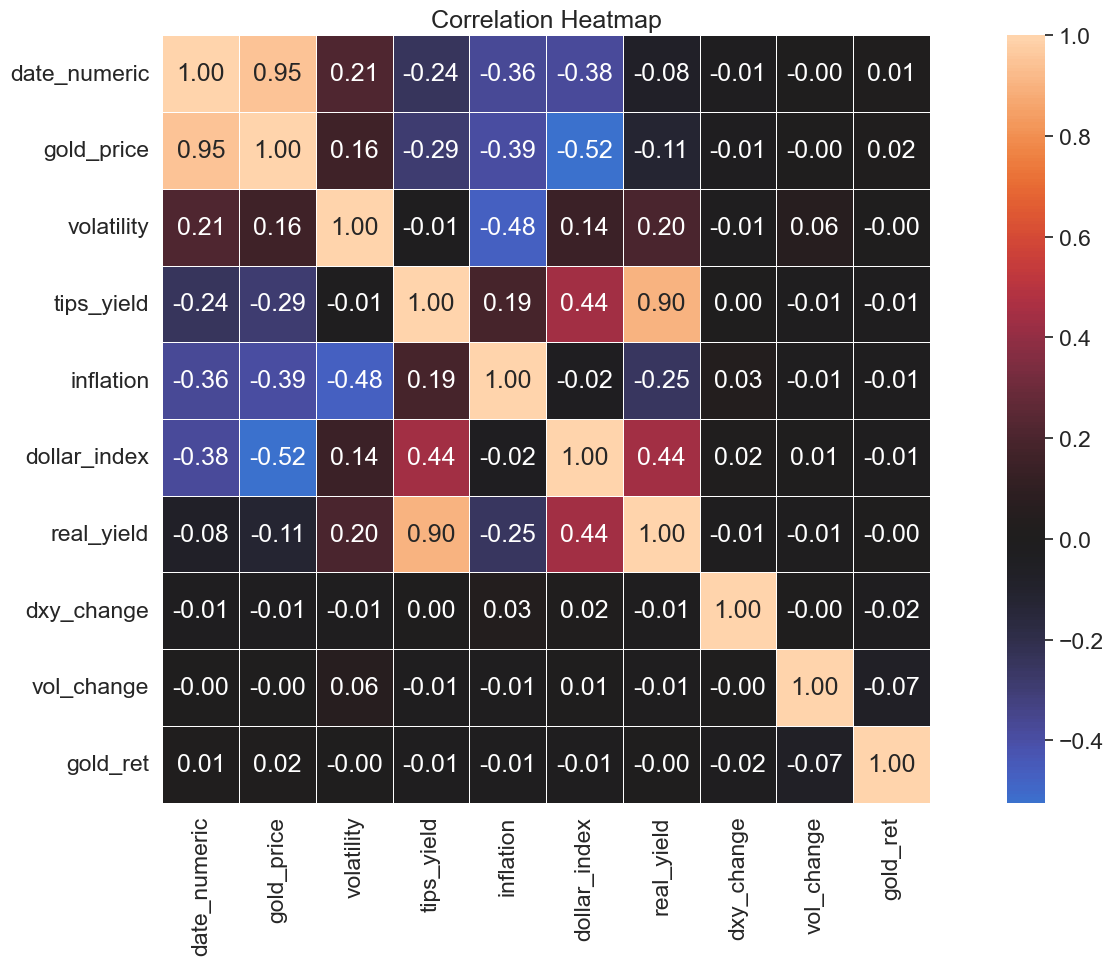

In [26]:
df_filled = d.copy()
df_filled['date_numeric'] = (df_filled.index - df_filled.index.min()).days
correlation_columns = ['date_numeric', 'gold_price', 'volatility', 'tips_yield', 
                      'inflation', 'dollar_index', 'real_yield', 'dxy_change', 'vol_change', 'gold_ret']

corr_matrix = df_filled[correlation_columns].corr()

sns.set(font_scale=1.5)
plt.figure(figsize=(16,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [27]:
used_features = ["date_numeric", "volatility", "tips_yield", "inflation", "dollar_index"]
x = df_filled[used_features].values
y = df_filled['gold_price'].values

In [28]:
## Linear Regression Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# Normalize
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Linear Regression
model = LinearRegression()
model.fit(x_train_scaled, y_train)

# Predictions
y_prediction = model.predict(x_test_scaled)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(f"r2 Score: {r2_score(y_test, y_prediction):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_prediction):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_prediction):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_prediction)):.2f}")

r2 Score: 0.9396
MAE: 139.40
MSE: 35557.78
RMSE: 188.57


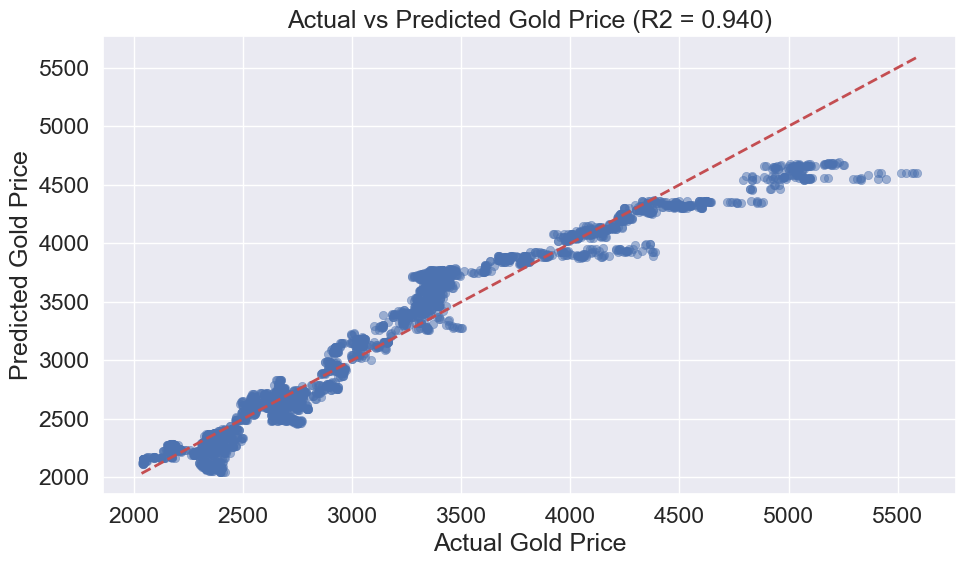

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_prediction, alpha=0.5, linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Gold Price')
plt.ylabel('Predicted Gold Price')
plt.title(f'Actual vs Predicted Gold Price (R2 = {r2_score(y_test, y_prediction):.3f})')
plt.tight_layout()
plt.show()

In [30]:
# Using Genetic Algorithm to eliminate the need for manual feature selection

In [31]:
#%pip install deap
from deap import base, creator, tools, algorithms
from sklearn.model_selection import cross_val_score
import random
import numpy as np
import matplotlib.pyplot as plt

# GA Configuration ---- Needs optimizations *
n_features = x.shape[1]
n_population = 50
n_generations = 100
mutation_rate = 0.3
crossover_rate = 0.5

# fitness function
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [32]:
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_features(individual):
    # Select features
    selected_features = [i for i, val in enumerate(individual) if val == 1]
    
    # Penalize if no features selected
    if len(selected_features) == 0:
        return -1e6,
    
    # Use selected features
    X_selected = x[:, selected_features]
    
    # Cross-validation score
    scores = cross_val_score(LinearRegression(), X_selected, y, 
                            cv=5, scoring='r2')
    
    # Return mean R2 score (with small penalty for more features)
    return np.mean(scores) - (0.01 * len(selected_features)),

toolbox.register("evaluate", eval_features)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

In [33]:
pop = toolbox.population(n=n_population)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=crossover_rate, mutpb=mutation_rate, 
                               ngen=n_generations, stats=stats, halloffame=hof, 
                               verbose=0)

In [34]:
# Get best features
best_individual = hof[0]
selected_indices = [i for i, val in enumerate(best_individual) if val == 1]
selected_features = [used_features[i] for i in selected_indices]

print(f"Best feature combination: {selected_features}")
print(f"Number of features selected: {len(selected_features)}")

Best feature combination: ['date_numeric', 'dollar_index']
Number of features selected: 2


In [35]:
# Train with selected features
X_optimized = df_filled[selected_features].values

# Split
x_train_opt, x_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_optimized, y, test_size=0.3, random_state=1
)

# Normalize
scaler_opt = StandardScaler()
x_train_opt_scaled = scaler_opt.fit_transform(x_train_opt)
x_test_opt_scaled = scaler_opt.transform(x_test_opt)

# Train
model_opt = LinearRegression()
model_opt.fit(x_train_opt_scaled, y_train_opt)

# Predict
y_pred_opt = model_opt.predict(x_test_opt_scaled)

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Original model metrics
original_r2 = r2_score(y_test, y_prediction)

# New model metrics
opt_r2 = r2_score(y_test_opt, y_pred_opt)
opt_mae = mean_absolute_error(y_test_opt, y_pred_opt)
opt_rmse = np.sqrt(mean_squared_error(y_test_opt, y_pred_opt))

print(f"R2 Score: {opt_r2:.4f}")
print(f"MAE: {opt_mae:.2f}")
print(f"RMSE: {opt_rmse:.2f}")
print(f"Improvement: {(opt_r2 - original_r2) * 100:.2f}%")

R2 Score: 0.9308
MAE: 135.99
RMSE: 201.96
Improvement: -0.89%


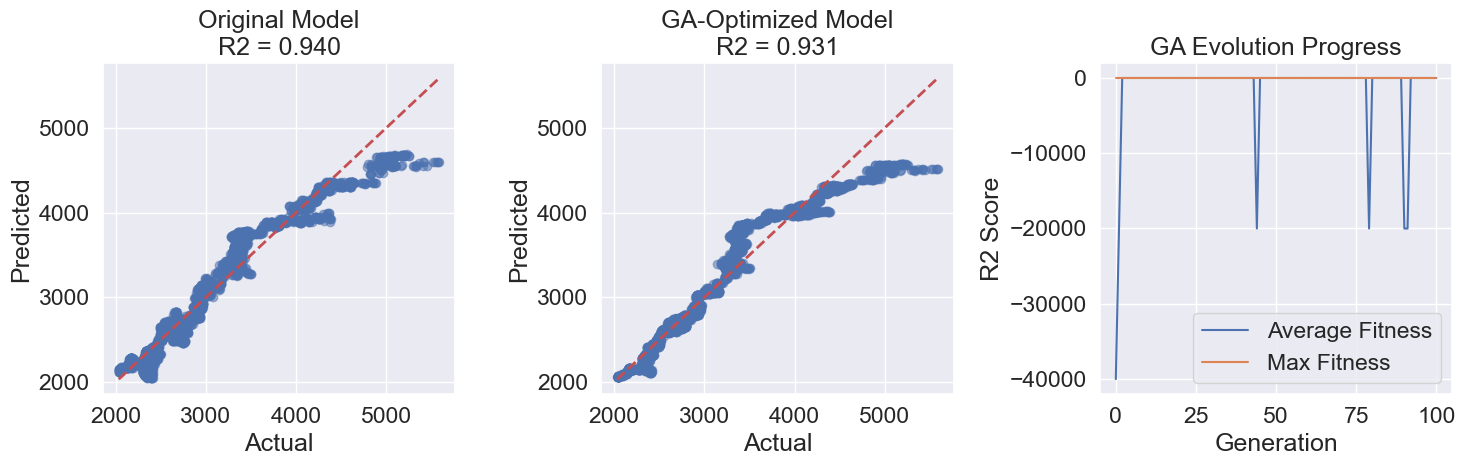

In [37]:
plt.figure(figsize=(15, 5))

# Original model
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Original Model\nR2 = {original_r2:.3f}')

# Optimized model
plt.subplot(1, 3, 2)
plt.scatter(y_test_opt, y_pred_opt, alpha=0.5)
plt.plot([y_test_opt.min(), y_test_opt.max()], [y_test_opt.min(), y_test_opt.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'GA-Optimized Model\nR2 = {opt_r2:.3f}')

# GA Evolution
plt.subplot(1, 3, 3)
gen = range(len(log.select("avg")))
plt.plot(gen, log.select("avg"), label="Average Fitness")
plt.plot(gen, log.select("max"), label="Max Fitness")
plt.xlabel("Generation")
plt.ylabel("R2 Score")
plt.title("GA Evolution Progress")
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# Feature importance
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model_opt.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coefficients.to_string(index=False))

     Feature  Coefficient
date_numeric   676.172870
dollar_index  -152.373292


In [39]:
# Using LSTM for prediction rather than correlation

72/72 [==============================] - 0s 844us/step
Correct LSTM RMSE: $63.38


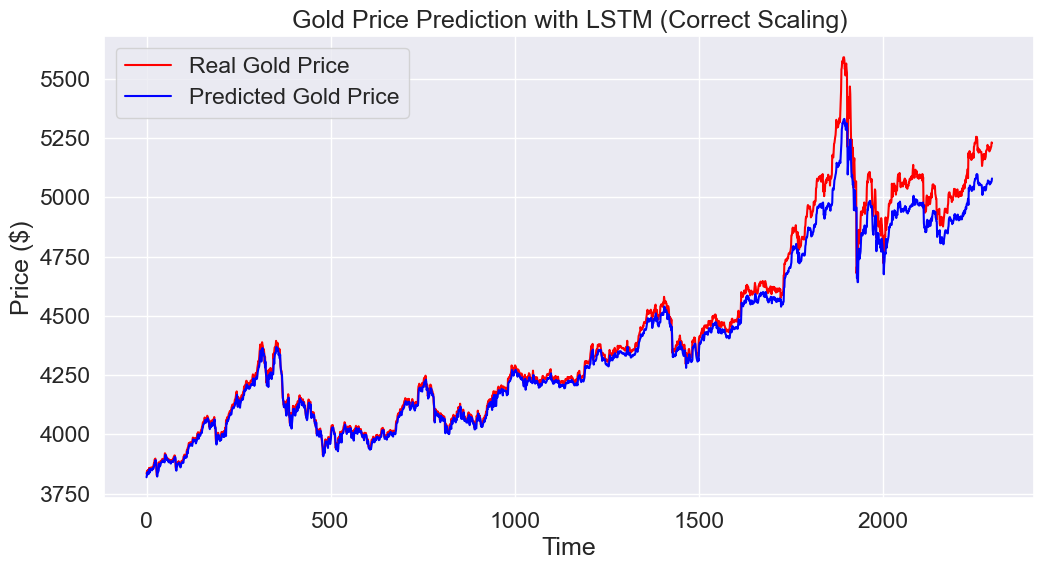

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Data
gold_prices = df_filled['gold_price'].values.reshape(-1, 1)

# Parameters
SEQ_LENGTH = 10
split_ratio = 0.8

X, y = [], []
for i in range(len(gold_prices) - SEQ_LENGTH):
    X.append(gold_prices[i:i+SEQ_LENGTH])
    y.append(gold_prices[i+SEQ_LENGTH])
X = np.array(X)  # shape: (samples, seq_length, 1)
y = np.array(y)

split_idx = int(split_ratio * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, 1)
scaler.fit(X_train_flat)

# Transform train and test
X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train_scaled = scaler.transform(y_train)
y_test_scaled = scaler.transform(y_test)

# Build model
model = Sequential([
    LSTM(50, input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, verbose=0)

# Predict
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print(f"Correct LSTM RMSE: ${rmse:.2f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_actual.flatten(), color='red', label='Real Gold Price')
plt.plot(y_pred.flatten(), color='blue', label='Predicted Gold Price')
plt.title('Gold Price Prediction with LSTM (Correct Scaling)')
plt.xlabel('Time')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
def predict_gold_price(model, scaler, current_price, days=1, history=None, seq_length=10):
    """
    Predict future gold prices
    
    Args:
        model: trained LSTM model
        scaler: fitted scaler
        current_price: today's gold price
        days: number of days to predict (1 for tomorrow)
        history: list of previous prices (optional)
        seq_length: sequence length used in training
    """
    if history is None:
        # Create synthetic history if not provided
        history = [current_price] * seq_length
    else:
        history = list(history) + [current_price]
        history = history[-seq_length:]
    
    predictions = []
    last_sequence = history.copy()
    
    for _ in range(days):
        # Prepare input
        input_seq = np.array(last_sequence[-seq_length:]).reshape(-1, 1)
        input_scaled = scaler.transform(input_seq).reshape(1, seq_length, 1)
        
        # Predict
        pred_scaled = model.predict(input_scaled, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)[0, 0]
        predictions.append(pred)
        
        # Update sequence for next prediction
        last_sequence.append(pred)
    
    return predictions[0] if days == 1 else predictions

Today's price: $1950.50
Predicted tomorrow's price: $1958.73

Next 7 days predictions:
Day 1: $1958.73
Day 2: $1965.89
Day 3: $1973.06
Day 4: $1980.05
Day 5: $1986.90
Day 6: $1993.64
Day 7: $2000.29


In [44]:
print('Today\'s Gold Price:', end=' ')
today_price = input().strip()
print('Predict for (days):', end=' ')
ndays = int(input().strip())
    
future_price = predict_gold_price(model, scaler, today_price, days=ndays)
for i, price in enumerate(future_price, 1):
    print(f"Day {i}: ${price:.2f}")

Today's Gold Price: 

 1977


Predict for (days): 

 10


Day 1: $1984.72
Day 2: $1991.48
Day 3: $1998.25
Day 4: $2004.87
Day 5: $2011.37
Day 6: $2017.77
Day 7: $2024.10
Day 8: $2030.35
Day 9: $2036.52
Day 10: $2042.62
